<a href="https://colab.research.google.com/github/MLfinal/Walmart-Recruiting---Store-Sales-Forecasting/blob/dev/models/deep_learning/tft/baseline_tft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Walmart Sales Forecasting — TFT baseline

This notebook trains the first Temporal Fusion Transformer baseline for the Walmart weekly sales task.

Main choices:
- validation is the last 39 weeks of `train.csv`, matching the Kaggle test horizon;
- evaluation metric is Kaggle-style WMAE on original sales scale;
- model uses historical sales, Store/Dept identity, holiday flag, and simple known calendar features;
- baseline is intentionally capped to a small top-series sample so it can finish on Colab in roughly 10 minutes;
- no economic/external covariates are used in this baseline yet;
- W&B logs config, training curves, validation WMAE, prediction tables, plots, checkpoints, and artifacts;
- no MLflow is used.

Run this on Colab. This notebook is written but not trained locally.

## Install dependencies

`pytorch-forecasting` provides the TFT implementation. If Colab asks to restart after install, restart runtime and run from the imports cell again.

In [ ]:
%pip install -q "torch>=2.3,<3" "pytorch-forecasting>=1.2,<2" "lightning>=2.2,<3" "wandb>=0.19,<1" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4" "scikit-learn>=1.4,<2"

## Imports and Drive mount

In [12]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import json
import math
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import wandb

try:
    from lightning.pytorch import Trainer, seed_everything
    from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
    from lightning.pytorch.loggers import WandbLogger
except Exception:
    from pytorch_lightning import Trainer, seed_everything
    from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
    from pytorch_lightning.loggers import WandbLogger

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE

pd.set_option('display.max_columns', 100)
print('torch', torch.__version__)
print('cuda available:', torch.cuda.is_available())

torch 2.11.0+cu128
cuda available: True


## Configuration

The first full-data attempt was too slow for Colab: about 1504 batches per epoch, with the first epoch projected around 10–13 minutes and instability warnings from non-finite loss. This baseline is therefore changed into a fast, controlled TFT sanity run. It trains on the top active Store-Dept series, uses a shorter encoder, clips negative target values, and hard-caps runtime with `max_time_minutes=10`.

In [14]:
SEED = 42
seed_everything(SEED, workers=True)

CONFIG = {
    "seed": SEED,
    "validation_weeks": 39,
    "encoder_weeks": 26,
    "top_n_series": 300,
    "holiday_weight": 5.0,
    "batch_size": 512,
    "max_epochs": 5,
    "max_time_minutes": 10,
    "patience": 2,
    "learning_rate": 1e-4,
    "hidden_size": 8,
    "attention_head_size": 1,
    "dropout": 0.10,
    "hidden_continuous_size": 4,
    "gradient_clip_val": 0.1,
    "num_workers": 0,
    "limit_train_batches": 20,
    "limit_val_batches": 5,
    "wandb_project": "Walmart-Recruiting---Store-Sales-Forecasting",
    "wandb_entity": "kende23-n-a",
    "wandb_group": "tft-baseline",
    "run_name": "tft_baseline_39w",
    "artifact_name": "tft-baseline-39w",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

DATA_DIR = Path('/content/drive/MyDrive/walmart_competition_data')
OUTPUT_DIR = Path('/content/artifacts/tft_baseline')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


{'seed': 42,
 'validation_weeks': 39,
 'encoder_weeks': 26,
 'top_n_series': 300,
 'holiday_weight': 5.0,
 'batch_size': 512,
 'max_epochs': 5,
 'max_time_minutes': 10,
 'patience': 2,
 'learning_rate': 0.0001,
 'hidden_size': 8,
 'attention_head_size': 1,
 'dropout': 0.1,
 'hidden_continuous_size': 4,
 'gradient_clip_val': 0.1,
 'num_workers': 0,
 'limit_train_batches': 20,
 'limit_val_batches': 5,
 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting',
 'wandb_entity': 'kende23-n-a',
 'wandb_group': 'tft-baseline',
 'run_name': 'tft_baseline_39w',
 'artifact_name': 'tft-baseline-39w',
 'device': 'cuda'}

## Load data

In [15]:
train_raw = pd.read_csv(DATA_DIR / 'train.csv', parse_dates=['Date'])
test_raw = pd.read_csv(DATA_DIR / 'test.csv', parse_dates=['Date'])

required_train = {'Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'}
required_test = {'Store', 'Dept', 'Date', 'IsHoliday'}
missing_train = required_train.difference(train_raw.columns)
missing_test = required_test.difference(test_raw.columns)
if missing_train or missing_test:
    raise ValueError({'missing_train': sorted(missing_train), 'missing_test': sorted(missing_test)})

train_raw = train_raw.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)
test_raw = test_raw.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

# Fast TFT baseline: keep only the highest-volume Store-Dept series.
# Full Walmart TFT creates too many sliding windows for Colab; full-data training belongs to later experiments.
if CONFIG['top_n_series'] is not None:
    top_series = (
        train_raw.groupby(['Store', 'Dept'], as_index=False)['Weekly_Sales']
        .sum()
        .sort_values('Weekly_Sales', ascending=False)
        .head(CONFIG['top_n_series'])[['Store', 'Dept']]
    )
    before_rows = len(train_raw)
    train_raw = train_raw.merge(top_series.assign(_keep=1), on=['Store', 'Dept'], how='inner').drop(columns='_keep')
    print({'top_n_series': CONFIG['top_n_series'], 'train_rows_before': before_rows, 'train_rows_after': len(train_raw)})

print('train', train_raw.shape, train_raw['Date'].min(), train_raw['Date'].max())
print('test ', test_raw.shape, test_raw['Date'].min(), test_raw['Date'].max())
display(train_raw.head())

{'top_n_series': 300, 'train_rows_before': 421570, 'train_rows_after': 42900}
train (42900, 5) 2010-02-05 00:00:00 2012-10-26 00:00:00
test  (115064, 4) 2012-11-02 00:00:00 2013-07-26 00:00:00


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,2,2010-02-05,50605.27,False
1,1,2,2010-02-12,44682.74,True
2,1,2,2010-02-19,47928.89,False
3,1,2,2010-02-26,44292.87,False
4,1,2,2010-03-05,48397.98,False


## Build TFT time-indexed data

TFT needs a long time-series table with:
- `time_idx`: integer week index;
- `group_ids`: Store and Dept;
- static categorical identifiers: Store, Dept;
- known future features: holiday flag and calendar features;
- unknown real target: Weekly_Sales.

This baseline does not use `features.csv` or `stores.csv`; those belong to later TFT experiments.

In [16]:
all_train_dates = pd.Index(sorted(train_raw['Date'].unique()), name='Date')
test_dates = pd.Index(sorted(test_raw['Date'].unique()), name='Date')
val_dates = all_train_dates[-CONFIG['validation_weeks']:]
fit_dates = all_train_dates[:-CONFIG['validation_weeks']]
split_pos = len(fit_dates)

if len(test_dates) != CONFIG['validation_weeks']:
    raise ValueError(f"Expected test horizon {CONFIG['validation_weeks']}, got {len(test_dates)}")
if len(fit_dates) < CONFIG['encoder_weeks'] + CONFIG['validation_weeks']:
    raise ValueError('Not enough fit history for encoder + decoder windows.')

date_to_idx = {date: idx for idx, date in enumerate(all_train_dates)}

def add_time_features(df: pd.DataFrame, date_to_idx: dict) -> pd.DataFrame:
    out = df.copy()
    out['time_idx'] = out['Date'].map(date_to_idx).astype(int)
    iso_week = out['Date'].dt.isocalendar().week.astype(int)
    month = out['Date'].dt.month.astype(int)
    out['week_sin'] = np.sin(2 * np.pi * iso_week / 52.0)
    out['week_cos'] = np.cos(2 * np.pi * iso_week / 52.0)
    out['month_sin'] = np.sin(2 * np.pi * month / 12.0)
    out['month_cos'] = np.cos(2 * np.pi * month / 12.0)
    out['Store'] = out['Store'].astype(str)
    out['Dept'] = out['Dept'].astype(str)
    out['IsHoliday'] = out['IsHoliday'].astype(int).astype(str)
    out['Weekly_Sales'] = out['Weekly_Sales'].clip(lower=0).astype(float)
    return out

data = add_time_features(train_raw, date_to_idx)

print({
    'n_rows': len(data),
    'n_series': data[['Store', 'Dept']].drop_duplicates().shape[0],
    'n_dates': len(all_train_dates),
    'fit_range': (str(fit_dates.min().date()), str(fit_dates.max().date())),
    'validation_range': (str(val_dates.min().date()), str(val_dates.max().date())),
    'test_horizon': len(test_dates),
})
display(data.head())

{'n_rows': 42900, 'n_series': 300, 'n_dates': 143, 'fit_range': ('2010-02-05', '2012-01-27'), 'validation_range': ('2012-02-03', '2012-10-26'), 'test_horizon': 39}


,Store,Dept,Date,Weekly_Sales,IsHoliday,time_idx,week_sin,week_cos,month_sin,month_cos
0,1,2,2010-02-05,50605.27,0,0,0.568065,0.822984,0.866025,5.000000e-01
1,1,2,2010-02-12,44682.74,1,1,0.663123,0.748511,0.866025,5.000000e-01
2,1,2,2010-02-19,47928.89,0,2,0.748511,0.663123,0.866025,5.000000e-01
3,1,2,2010-02-26,44292.87,0,3,0.822984,0.568065,0.866025,5.000000e-01
4,1,2,2010-03-05,48397.98,0,4,0.885456,0.464723,1.000000,6.123234e-17


## WMAE helpers and seasonal naive reference

In [17]:
def wmae(y_true: np.ndarray, y_pred: np.ndarray, is_holiday: np.ndarray, holiday_weight: float = 5.0) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    weights = np.where(np.asarray(is_holiday, dtype=bool), holiday_weight, 1.0)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))

sales_panel = (
    train_raw.pivot_table(index=['Store', 'Dept'], columns='Date', values='Weekly_Sales', aggfunc='sum')
    .reindex(columns=all_train_dates)
    .fillna(0.0)
    .sort_index()
)

holiday_by_date = (
    train_raw[['Date', 'IsHoliday']]
    .drop_duplicates('Date')
    .set_index('Date')
    .reindex(all_train_dates)['IsHoliday']
    .fillna(False)
    .astype(bool)
)

values = sales_panel.to_numpy(dtype=np.float32)
holiday_flags = holiday_by_date.to_numpy(dtype=bool)
actual_val = values[:, split_pos:split_pos + CONFIG['validation_weeks']]
seasonal_naive = values[:, split_pos - 52:split_pos - 52 + CONFIG['validation_weeks']]
val_holidays_matrix = np.tile(holiday_flags[split_pos:split_pos + CONFIG['validation_weeks']], (values.shape[0], 1))
seasonal_naive_wmae = wmae(actual_val.ravel(), seasonal_naive.ravel(), val_holidays_matrix.ravel(), CONFIG['holiday_weight'])

print({
    'n_series': len(sales_panel),
    'validation_series': values.shape[0],
    'seasonal_naive_wmae': seasonal_naive_wmae,
})

{'n_series': 300, 'validation_series': 300, 'seasonal_naive_wmae': 6026.2907744625445}


## Create TimeSeriesDataSet objects

Training uses only rows before validation. Validation is created from the full table with `predict=True`, so each Store-Dept series gets one direct 39-week forecast.

In [18]:
training_cutoff = split_pos - 1

training_dataset = TimeSeriesDataSet(
    data[data.time_idx <= training_cutoff],
    time_idx='time_idx',
    target='Weekly_Sales',
    group_ids=['Store', 'Dept'],
    min_encoder_length=CONFIG['encoder_weeks'] // 2,
    max_encoder_length=CONFIG['encoder_weeks'],
    min_prediction_length=CONFIG['validation_weeks'],
    max_prediction_length=CONFIG['validation_weeks'],
    static_categoricals=['Store', 'Dept'],
    time_varying_known_categoricals=['IsHoliday'],
    time_varying_known_reals=['time_idx', 'week_sin', 'week_cos', 'month_sin', 'month_cos'],
    time_varying_unknown_reals=['Weekly_Sales'],
    target_normalizer=GroupNormalizer(groups=['Store', 'Dept'], center=True),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    data,
    predict=True,
    stop_randomization=True,
    min_prediction_idx=split_pos,
)

train_loader = training_dataset.to_dataloader(
    train=True,
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers'],
)
val_loader = validation_dataset.to_dataloader(
    train=False,
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers'],
)

print({
    'train_batches': len(train_loader),
    'validation_batches': len(val_loader),
    'training_samples': len(training_dataset),
    'validation_samples': len(validation_dataset),
})

{'train_batches': 38, 'validation_batches': 1, 'training_samples': 19800, 'validation_samples': 300}


## Optional sanity check: PyTorch Forecasting naive baseline

This is separate from our 52-week seasonal naive. It is useful as a library sanity check before training TFT.

In [19]:
baseline_model = Baseline()
baseline_predictions = baseline_model.predict(val_loader, return_y=True)
print('PyTorch Forecasting Baseline object ran successfully.')

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

PyTorch Forecasting Baseline object ran successfully.


## Start W&B and build TFT

In [20]:
wandb_logger = WandbLogger(
    project=CONFIG['wandb_project'],
    entity=CONFIG['wandb_entity'],
    group=CONFIG['wandb_group'],
    name=CONFIG['run_name'],
    job_type='baseline_train',
    log_model=False,
    config=CONFIG,
)

run = wandb_logger.experiment
run.config.update({
    'n_series': int(data[['Store', 'Dept']].drop_duplicates().shape[0]),
    'n_train_rows': int(len(data[data.time_idx <= training_cutoff])),
    'n_validation_rows': int(len(data[data.time_idx >= split_pos])),
    'fit_start': str(fit_dates.min().date()),
    'fit_end': str(fit_dates.max().date()),
    'validation_start': str(val_dates.min().date()),
    'validation_end': str(val_dates.max().date()),
    'seasonal_naive_wmae': float(seasonal_naive_wmae),
}, allow_val_change=True)

checkpoint_callback = ModelCheckpoint(
    dirpath=str(OUTPUT_DIR / 'checkpoints'),
    filename='tft-baseline-{epoch:02d}-{val_loss:.4f}',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
)
early_stop_callback = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=CONFIG['patience'],
    mode='min',
)
lr_monitor = LearningRateMonitor(logging_interval='epoch')

tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=CONFIG['learning_rate'],
    hidden_size=CONFIG['hidden_size'],
    attention_head_size=CONFIG['attention_head_size'],
    dropout=CONFIG['dropout'],
    hidden_continuous_size=CONFIG['hidden_continuous_size'],
    loss=MAE(),
    optimizer='adam',
    log_interval=20,
    reduce_on_plateau_patience=3,
)

print(f'Number of parameters: {tft.size() / 1e3:.1f}k')
run.summary['model_parameters'] = int(tft.size())

Number of parameters: 8.4k


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loggers/wandb.py:400: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


## Train

This cell starts training. Do not run it locally in Codex; run it on Colab/GPU.

In [21]:
trainer = Trainer(
    max_epochs=CONFIG['max_epochs'],
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    gradient_clip_val=CONFIG['gradient_clip_val'],
    callbacks=[early_stop_callback, checkpoint_callback, lr_monitor],
    logger=wandb_logger,
    enable_checkpointing=True,
    limit_train_batches=CONFIG['limit_train_batches'],
    limit_val_batches=CONFIG['limit_val_batches'],
    max_time={"minutes": CONFIG['max_time_minutes']},
    log_every_n_steps=20,
)

trainer.fit(
    tft,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

best_checkpoint_path = checkpoint_callback.best_model_path
best_val_loss = float(checkpoint_callback.best_model_score.cpu()) if checkpoint_callback.best_model_score is not None else math.nan
print({'best_checkpoint_path': best_checkpoint_path, 'best_val_loss': best_val_loss})
run.summary['best_checkpoint_path'] = best_checkpoint_path
run.summary['best_val_loss'] = best_val_loss

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /content/artifacts/tft_baseline/checkpoints exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
IN

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ MAE                             │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    554 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │     80 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │    812 │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  1.8 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  1.5 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │    304 │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │    304 │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │    304 │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │    304 │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │    576 │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │    576 │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    144 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     16 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │    368 │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    280 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    160 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │    304 │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    160 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │      9 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 8.4 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 8.4 K                                                                                                
Total estimated model params size (MB): 0.033                                                                      
Modules in train mode: 406                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: `Trainer.fit` stopped: `max_epochs=5` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


{'best_checkpoint_path': '/content/artifacts/tft_baseline/checkpoints/tft-baseline-epoch=03-val_loss=7290.1284.ckpt', 'best_val_loss': 7290.12841796875}


## Evaluate validation WMAE on original sales scale

We select models by Kaggle-style WMAE, not by TFT's internal normalized validation loss.

In [22]:
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_checkpoint_path)
best_tft.eval()

prediction = best_tft.predict(
    val_loader,
    mode='prediction',
    return_index=True,
    return_y=True,
    trainer_kwargs={
        'accelerator': 'gpu' if torch.cuda.is_available() else 'cpu',
        'devices': 1,
    },
)

# pytorch-forecasting returns a Prediction object in recent versions.
pred_values = prediction.output.detach().cpu().numpy() if torch.is_tensor(prediction.output) else np.asarray(prediction.output)
index_df = prediction.index.reset_index(drop=True).copy()

if pred_values.ndim == 3:
    pred_values = pred_values[..., 0]
if pred_values.shape[1] != CONFIG['validation_weeks']:
    raise ValueError(f"Expected prediction horizon {CONFIG['validation_weeks']}, got {pred_values.shape}")

actual_lookup = sales_panel.copy()
records = []
for row_idx, row in index_df.iterrows():
    store = int(row['Store'])
    dept = int(row['Dept'])
    if (store, dept) not in actual_lookup.index:
        continue
    for horizon_idx, date in enumerate(val_dates):
        actual = float(actual_lookup.loc[(store, dept), date])
        pred = float(max(pred_values[row_idx, horizon_idx], 0.0))
        is_holiday = bool(holiday_by_date.loc[date])
        records.append({
            'Store': store,
            'Dept': dept,
            'Date': pd.Timestamp(date),
            'IsHoliday': is_holiday,
            'Weekly_Sales': actual,
            'Prediction': pred,
            'AbsError': abs(actual - pred),
        })

val_pred_df = pd.DataFrame(records)
if val_pred_df.empty:
    raise ValueError('No validation predictions were aligned. Check prediction.index Store/Dept columns.')

validation_wmae = wmae(
    val_pred_df['Weekly_Sales'].to_numpy(),
    val_pred_df['Prediction'].to_numpy(),
    val_pred_df['IsHoliday'].to_numpy(),
    CONFIG['holiday_weight'],
)

improvement_vs_seasonal = 100.0 * (seasonal_naive_wmae - validation_wmae) / seasonal_naive_wmae
print({
    'validation_wmae': validation_wmae,
    'seasonal_naive_wmae': seasonal_naive_wmae,
    'improvement_vs_seasonal_naive_pct': improvement_vs_seasonal,
    'prediction_rows': len(val_pred_df),
})

run.summary['best_validation_wmae'] = float(validation_wmae)
run.summary['seasonal_naive_wmae'] = float(seasonal_naive_wmae)
run.summary['best_improvement_vs_seasonal_naive_pct'] = float(improvement_vs_seasonal)
wandb.log({
    'validation/wmae': float(validation_wmae),
    'validation/seasonal_naive_wmae': float(seasonal_naive_wmae),
    'validation/improvement_vs_seasonal_naive_pct': float(improvement_vs_seasonal),
})

display(val_pred_df.head())

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

{'validation_wmae': 7801.898566783023, 'seasonal_naive_wmae': 6026.2907744625445, 'improvement_vs_seasonal_naive_pct': -29.464356413814702, 'prediction_rows': 11700}


,Store,Dept,Date,IsHoliday,Weekly_Sales,Prediction,AbsError
0,1,2,2012-02-03,False,54322.24,45741.304688,8580.935312
1,1,2,2012-02-10,True,50581.06,45704.664062,4876.395937
2,1,2,2012-02-17,False,46085.47,45656.304688,429.165313
3,1,2,2012-02-24,False,47080.12,45611.824219,1468.295781
4,1,2,2012-03-02,False,52608.51,45385.722656,7222.787344


## Save validation predictions, plots, checkpoint metadata, and W&B artifact

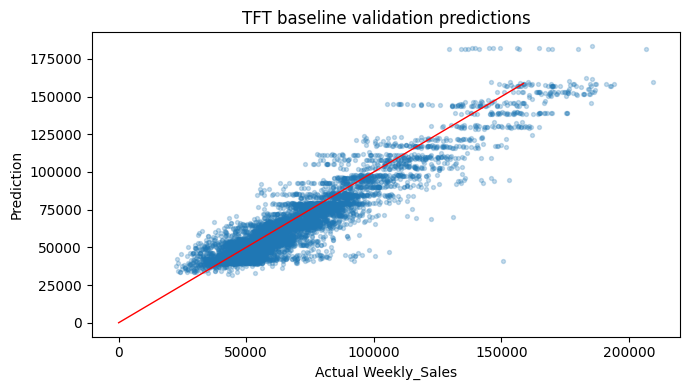

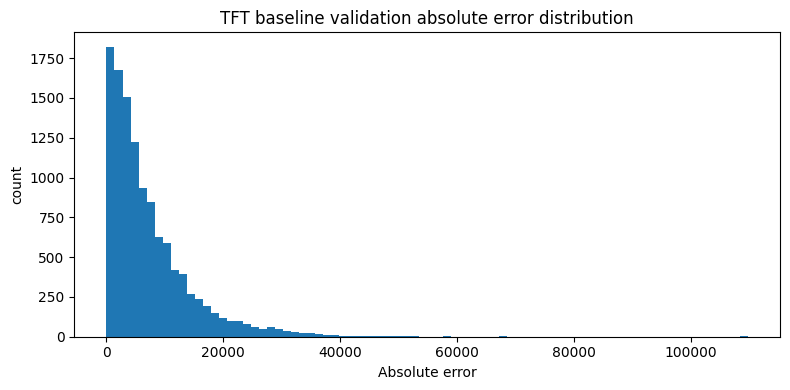

{'model': 'TemporalFusionTransformer',
 'experiment': 'tft_baseline_39w',
 'best_checkpoint_path': '/content/artifacts/tft_baseline/checkpoints/tft-baseline-epoch=03-val_loss=7290.1284.ckpt',
 'best_val_loss': 7290.12841796875,
 'best_validation_wmae': 7801.898566783023,
 'seasonal_naive_wmae': 6026.2907744625445,
 'improvement_vs_seasonal_naive_pct': -29.464356413814702,
 'validation_weeks': 39,
 'encoder_weeks': 26,
 'n_series': 300,
 'train_date_start': '2010-02-05',
 'train_date_end': '2012-01-27',
 'validation_date_start': '2012-02-03',
 'validation_date_end': '2012-10-26',
 'config': {'seed': 42,
  'validation_weeks': 39,
  'encoder_weeks': 26,
  'top_n_series': 300,
  'holiday_weight': 5.0,
  'batch_size': 512,
  'max_epochs': 5,
  'max_time_minutes': 10,
  'patience': 2,
  'learning_rate': 0.0001,
  'hidden_size': 8,
  'attention_head_size': 1,
  'dropout': 0.1,
  'hidden_continuous_size': 4,
  'gradient_clip_val': 0.1,
  'num_workers': 0,
  'limit_train_batches': 20,
  'limit_

In [23]:
val_pred_path = OUTPUT_DIR / 'tft_baseline_validation_predictions.csv'
val_pred_df.to_csv(val_pred_path, index=False)

summary = {
    'model': 'TemporalFusionTransformer',
    'experiment': 'tft_baseline_39w',
    'best_checkpoint_path': str(best_checkpoint_path),
    'best_val_loss': best_val_loss,
    'best_validation_wmae': float(validation_wmae),
    'seasonal_naive_wmae': float(seasonal_naive_wmae),
    'improvement_vs_seasonal_naive_pct': float(improvement_vs_seasonal),
    'validation_weeks': CONFIG['validation_weeks'],
    'encoder_weeks': CONFIG['encoder_weeks'],
    'n_series': int(data[['Store', 'Dept']].drop_duplicates().shape[0]),
    'train_date_start': str(fit_dates.min().date()),
    'train_date_end': str(fit_dates.max().date()),
    'validation_date_start': str(val_dates.min().date()),
    'validation_date_end': str(val_dates.max().date()),
    'config': CONFIG,
}
summary_path = OUTPUT_DIR / 'tft_baseline_summary.json'
summary_path.write_text(json.dumps(summary, indent=2))

fig, ax = plt.subplots(figsize=(7, 4))
sample = val_pred_df.sample(min(7000, len(val_pred_df)), random_state=SEED)
ax.scatter(sample['Weekly_Sales'], sample['Prediction'], s=8, alpha=0.25)
max_axis = np.nanpercentile(sample[['Weekly_Sales', 'Prediction']].to_numpy(), 99)
ax.plot([0, max_axis], [0, max_axis], color='red', linewidth=1)
ax.set_title('TFT baseline validation predictions')
ax.set_xlabel('Actual Weekly_Sales')
ax.set_ylabel('Prediction')
plt.tight_layout()
scatter_path = OUTPUT_DIR / 'tft_baseline_validation_scatter.png'
fig.savefig(scatter_path, dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(val_pred_df['AbsError'], bins=80)
ax.set_title('TFT baseline validation absolute error distribution')
ax.set_xlabel('Absolute error')
ax.set_ylabel('count')
plt.tight_layout()
error_hist_path = OUTPUT_DIR / 'tft_baseline_abs_error_hist.png'
fig.savefig(error_hist_path, dpi=160)
plt.show()

artifact = wandb.Artifact(CONFIG['artifact_name'], type='model')
artifact.add_file(str(best_checkpoint_path), name='tft_baseline_best.ckpt')
artifact.add_file(str(summary_path))
artifact.add_file(str(val_pred_path))
artifact.add_file(str(scatter_path))
artifact.add_file(str(error_hist_path))
run.log_artifact(artifact, aliases=['baseline', 'latest'])

wandb.log({
    'validation/prediction_table': wandb.Table(dataframe=val_pred_df.sample(min(20000, len(val_pred_df)), random_state=SEED)),
    'validation/scatter': wandb.Image(str(scatter_path)),
    'validation/abs_error_histogram': wandb.Image(str(error_hist_path)),
})

summary

## Optional interpretation helpers

TFT can expose attention/importance plots. These are useful, but they can be slow. Run only after the baseline result is saved.

In [24]:
RUN_INTERPRETATION = False

if RUN_INTERPRETATION:
    raw_predictions = best_tft.predict(
        val_loader,
        mode='raw',
        return_x=True,
        trainer_kwargs={
            'accelerator': 'gpu' if torch.cuda.is_available() else 'cpu',
            'devices': 1,
        },
    )
    interpretation = best_tft.interpret_output(raw_predictions.output, reduction='sum')
    figs = best_tft.plot_interpretation(interpretation)
    for name, fig in figs.items():
        fig_path = OUTPUT_DIR / f'tft_interpretation_{name}.png'
        fig.savefig(fig_path, dpi=160, bbox_inches='tight')
        wandb.log({f'interpretation/{name}': wandb.Image(str(fig_path))})
else:
    print('Interpretation skipped. Set RUN_INTERPRETATION=True after baseline training if needed.')

Interpretation skipped. Set RUN_INTERPRETATION=True after baseline training if needed.


## Finish W&B run

In [25]:
wandb.finish()

epoch,▁▁▁▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▅▅▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇████▂
lr-Adam,███████▃▃▁▁▁▁▁
train_loss_epoch,▂▁▁▁▁▁▁▁▁██▇▇▇
train_loss_step,▂▂▂▂▂▂▂▁▁▂▁▂▁▁▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▂▁▁▁▁▁▁▂▂█
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇█
val_MAE,█████████▁▁▁▁▁
val_MAPE,▆▇███▇█▇▇▁▁▁▁▁
val_RMSE,▁▁▁▁▁▁▁▁▁█████
val_SMAPE,█████████▁▁▁▁▁
val_loss,█████████▁▁▁▁▁
+3,...
